# Projeto de Segmentação de Clientes (Projeto Final)

Este notebook documenta o processo de análise e modelagem para o TCC da Pós-Graduação em Ciência de Dados com Inteligência Artificial da UniSENAI.

O projeto segue a metodologia **CRISP-DM**.

Aluno: Cláudio Ferreira Neves
---

## 1. Entendimento do Negócio (Business Understanding)

**Contexto**: Um supermercado utiliza um programa de fidelidade e registra informações básicas de clientes, tais como idade, gênero, renda anual estimada e uma pontuação interna de gastos (spending score), atribuída a partir do comportamento de compra.

**Problema**: Apesar de possuir dados relevantes, o supermercado não dispõe de uma segmentação estruturada de clientes e, por isso, tende a adotar ações comerciais e de relacionamento pouco personalizadas, reduzindo a eficiência de campanhas e ofertas direcionadas.

**Pergunta-problema**: É possível identificar grupos de clientes com perfis semelhantes, a partir das variáveis de renda e pontuação de gastos, de forma a apoiar ações de marketing mais direcionadas?

**Objetivo geral**: Aplicar uma técnica de aprendizado não supervisionado (clusterização) para segmentar clientes em grupos distintos com base em renda anual e pontuação de gastos.

**Objetivos específicos**:

* Realizar análise exploratória para compreender distribuição e relações entre variáveis.
* Preparar os dados (tratamento básico e padronização, quando aplicável) para suportar a clusterização.
* Definir um número adequado de clusters com base em critério(s) simples e interpretáveis (ex.: método do cotovelo).
* Construir e interpretar os clusters gerados, descrevendo perfis típicos por grupo.

**Valor esperado (Meta)**: Disponibilizar uma segmentação que permita ao supermercado ajustar estratégias de marketing e relacionamento, como campanhas personalizadas, ações de fidelização e priorização de ofertas por perfil de consumo.

In [1]:
# --- Passo 1: 
# Imports Principais

%matplotlib inline 

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import os
import pathlib

import plotly.express as px
from platform import python_version

import plotly.express as px
from sklearn.cluster import KMeans # Garantir que o import está na célula


# Imports específicos de Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # Importa a métrica de silhueta

# Imports de análise e display
from ydata_profiling import ProfileReport
from IPython.display import display

print("Bibliotecas carregadas com sucesso.")
print(f"Matplotlib backend: {matplotlib.get_backend()}")

C:\Users\s2bcl\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas carregadas com sucesso.
Matplotlib backend: inline


In [2]:
# --- Passo 2:
# Verificação de Versões

bibliotecas = {
    "Pandas": pd,
    "Matplotlib": matplotlib,
    "Seaborn": sns,
    "NumPy": np,
    "Scikit-Learn": sklearn,
}

print("Versões das bibliotecas:\n")
print(f"{'':-^20} | {'':-^10}")
print(f"{'Biblioteca':^20} | {'Versão':^10}")
print(f"{'':-^20} | {'':-^10}")

for nome, biblioteca in sorted(bibliotecas.items()):
    print(f"{nome:<20} | {biblioteca.__version__:>10}")

print()
print(f"Versão do Python: {python_version()}")

Versões das bibliotecas:

-------------------- | ----------
     Biblioteca      |   Versão  
-------------------- | ----------
Matplotlib           |     3.10.0
NumPy                |      2.3.3
Pandas               |      2.3.3
Scikit-Learn         |      1.7.2
Seaborn              |     0.13.2

Versão do Python: 3.11.9


## 2. Entendimento dos Dados (Data Understanding)

Nesta etapa, vamos carregar os dados, verificar sua qualidade e estrutura, e realizar uma análise exploratória (EDA) para identificar padrões iniciais.
Primeiro, definimos os caminhos para salvar nossos relatórios e o link do dataset público (Kaggle).

In [3]:
# --- Passo 3:
# Definição de Constantes e Caminhos
# 1. Definir o link dos dados (URL)

DATA_LINK = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"

# 2. Diagnóstico: Imprimir o diretório de trabalho atual
current_dir = pathlib.Path.cwd()
print(f"Diretório de Trabalho Atual (CWD): {current_dir}")

# 3. Definir o caminho da pasta de relatórios
REPORTS_DIR = "../reports" 

# 4. Criar a pasta 'reports' SE ELA NÃO EXISTIR
try:
    os.makedirs(REPORTS_DIR, exist_ok=True)
    # os.path.abspath() mostra o caminho completo para termos certeza
    print(f"Pasta de relatórios foi verificada/criada em: {os.path.abspath(REPORTS_DIR)}")
except Exception as e:
    print(f"ERRO AO CRIAR A PASTA 'reports': {e}")

# 5. Definir os nomes dos arquivos de saída
EDA_HTML_FILE = os.path.join(REPORTS_DIR, "eda_mall_customers.html")
PAIRPLOT_FILE = os.path.join(REPORTS_DIR, "pairplot.png")
ELBOW_PLOT_FILE = os.path.join(REPORTS_DIR, "elbow_plot.png")
CLUSTER_PLOT_FILE = os.path.join(REPORTS_DIR, "cluster_plot_2d.png")

# --- LINHA ADICIONADA ---
PROFILES_PLOT_FILE = os.path.join(REPORTS_DIR, "perfis_detalhados_clusters.png")
# --- FIM DA LINHA ADICIONADA ---

print("\nCaminhos de salvamento definidos com sucesso.")

Diretório de Trabalho Atual (CWD): c:\Users\s2bcl\OneDrive\Documents\tcc_dataScience\24. Projeto\notebooks
Pasta de relatórios foi verificada/criada em: c:\Users\s2bcl\OneDrive\Documents\tcc_dataScience\24. Projeto\reports

Caminhos de salvamento definidos com sucesso.


In [4]:
# --- Passo 4: 
# Carregamento e Limpeza Inicial dos Dados ---
# O código que depende de 'df' está dentro do bloco try

try:
    # Carregar o dataset
    df = pd.read_csv(DATA_LINK, sep=",")
    print("Dados carregados com sucesso.")
    
    # Renomear colunas para melhor legibilidade
    df.columns = ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
    
    # Exibir as primeiras linhas e informações
    print("Amostra dos dados:")
    display(df.head())
    
    print("\nInformações do DataFrame:")
    df.info()
    
    print("\nVerificação de valores nulos (não deve haver nenhuma):")
    display(df.isnull().sum())

except Exception as e:
    print(f"Erro CRÍTICO ao carregar ou processar dados: {e}")
    print("A execução da célula foi interrompida.")

Dados carregados com sucesso.
Amostra dos dados:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Verificação de valores nulos (não deve haver nenhuma):


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### 2.1 Análise Exploratória de Dados (EDA)

Geramos um relatório automático com `ydata-profiling` para uma visão geral e um `pairplot` para analisar visualmente as correlações entre as variáveis.

In [5]:
# --- Passo 5: 
# Geração do Relatório EDA (ProfileReport)

print(f"Gerando ProfileReport... (Isso pode levar alguns segundos)")
try:
    # 1. Criar o relatório exploratório
    profile = ProfileReport(df, title="Relatório EDA - Mall Customers", explorative=True)

    # 2. Exportar para HTML usando o caminho que definimos
    profile.to_file(EDA_HTML_FILE)
    print(f"Relatório EDA salvo com sucesso em: {EDA_HTML_FILE}")
    print(f"Abra o arquivo acima no seu navegador para ver o relatório.")

except Exception as e:
    print(f"Ocorreu um erro ao gerar o ProfileReport: {e}")

Gerando ProfileReport... (Isso pode levar alguns segundos)


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 60.63it/s]

Relatório EDA salvo com sucesso em: ../reports\eda_mall_customers.html
Abra o arquivo acima no seu navegador para ver o relatório.


Gerando Pairplot para análise visual...
Gráfico pairplot salvo com sucesso em: ../reports\pairplot.png


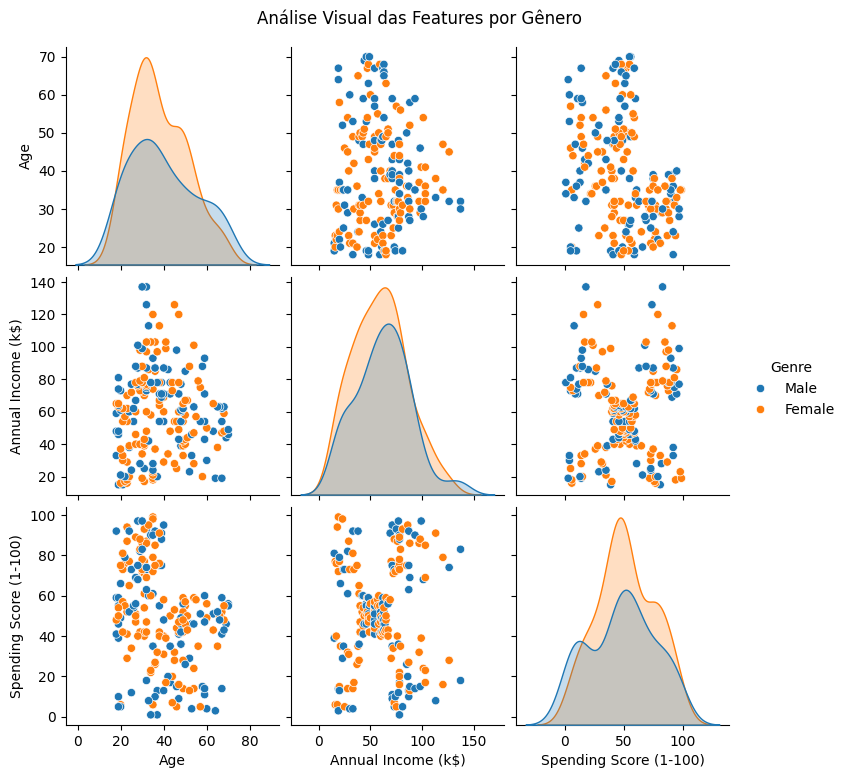

In [6]:
# --- Passo 6: 
# Análise Visual (Pairplot)
# Focar nas relações entre as variáveis

# Remover o CustomerID para o pairplot, pois não é uma feature de análise
df_plot = df.drop('CustomerID', axis=1)

print("Gerando Pairplot para análise visual...")
# hue='Genre' nos permite ver se há diferenças claras entre gêneros
g = sns.pairplot(df_plot, hue='Genre', diag_kind='kde')

# Adiciona um título geral
g.fig.suptitle("Análise Visual das Features por Gênero", y=1.03)

# Salvar o gráfico na pasta 'reports'
try:
    plt.savefig(PAIRPLOT_FILE, dpi=300) # dpi=300 para alta qualidade
    print(f"Gráfico pairplot salvo com sucesso em: {PAIRPLOT_FILE}")
except Exception as e:
    print(f"Erro ao salvar o pairplot: {e}")

# Exibe o gráfico no notebook
plt.show()

## 3. Preparação dos Dados (Data Preparation)

**Seleção de Features (Engenharia de Atributos):**
Baseado no `Pairplot` e no `ProfileReport`, a relação mais promissora para segmentação é entre `Annual Income (k$)` (Renda Anual) e `Spending Score (1-100)` (Pontuação de Gastos). As outras variáveis (Idade, Gênero) não mostraram grupos visuais claros. Vamos focar nessas duas.

**Padronização (Scaling):**
O algoritmo K-Means é baseado em distância euclidiana. Variáveis com escalas diferentes (ex: Renda de 15k a 137k e Pontuação de 1 a 100) podem distorcer o modelo. A Renda teria um peso muito maior. Para resolver isso, vamos padronizar (Standardization) ambas as features para que tenham média 0 e desvio padrão 1.

In [7]:
# --- Passo 7: 
# Preparação dos Dados (Seleção e Padronização)

# 1. Selecionar as features
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 2. Inicializar o Scaler (Padronizador)
scaler = StandardScaler()

# 3. Treinar o scaler e transformar as features
features_scaled = scaler.fit_transform(features)

# Exibir os 5 primeiros registros padronizados
print("Features padronizadas (5 primeiras linhas):")
print(features_scaled[:5])

Features padronizadas (5 primeiras linhas):
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [ ]:
# Instalação do Plotly --- (Não esqueça: Execute esta célula apenas uma vez)
# %pip install plotly

## 4. Modelagem

A técnica escolhida, conforme sugerido no escopo do TCC, é o **K-Means**, um algoritmo de agrupamento (clusterização).

O maior desafio do K-Means é definir o número ideal de clusters (K). Para fazer isso de forma justificada, usaremos o **Método do Cotovelo (Elbow Method)**.

Calculando Inércia (WCSS) para K de 1 a 10...
Gerando gráfico estático (para o relatório)...
Gráfico do Cotovelo salvo com sucesso em: ../reports\elbow_plot.png


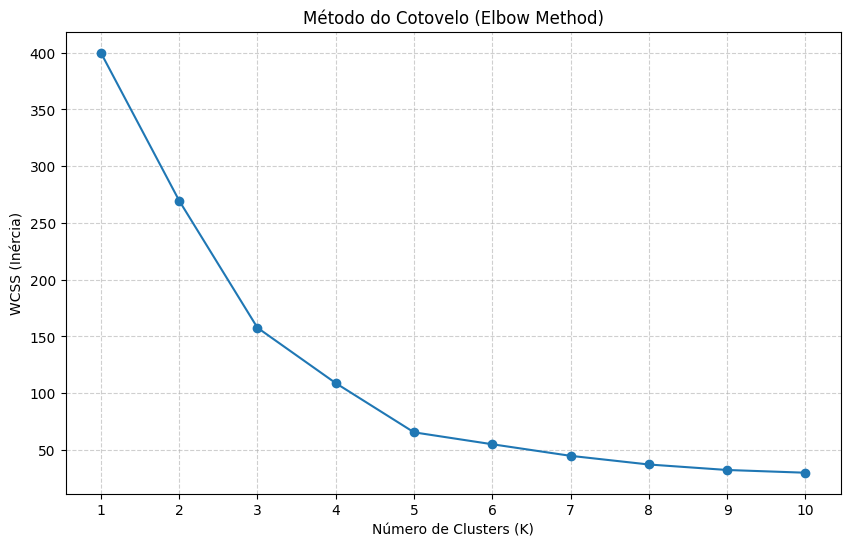


Gerando gráfico interativo (Plotly)...


In [8]:
# --- Passo 8:  
# Método do Cotovelo (Estático + Interativo)
# Importar o plotly express (px)

wcss = [] # Lista para armazenar a Inércia (WCSS)
K_range = range(1, 11) # Vamos testar de 1 a 10 clusters

print("Calculando Inércia (WCSS) para K de 1 a 10...")
for k in K_range:
    kmeans = KMeans(
        n_clusters=k,       # O número de clusters que estamos testando
        init='k-means++',   # Método de inicialização inteligente
        random_state=42,    # Para reprodutibilidade
        n_init=10           # Rodar 10x e pegar o melhor resultado
    )
    kmeans.fit(features_scaled)
    wcss.append(kmeans.inertia_) # 'inertia_' é o valor do WCSS

# --- Parte 1: Gráfico Estático (para o Relatório PDF) ---
print("Gerando gráfico estático (para o relatório)...")
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'o-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Inércia)')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Salvar o gráfico
try:
    plt.savefig(ELBOW_PLOT_FILE, dpi=300)
    print(f"Gráfico do Cotovelo salvo com sucesso em: {ELBOW_PLOT_FILE}")
except Exception as e:
    print(f"Erro ao salvar o gráfico do cotovelo: {e}")
    
# Exibe o gráfico estático no notebook
plt.show()

# --- Parte 2: Gráfico Interativo (para o Notebook) ---
print("\nGerando gráfico interativo (Plotly)...")

# Criar um dataframe para o Plotly
df_elbow = pd.DataFrame({
    'Número de Clusters (K)': K_range, 
    'WCSS (Inércia)': wcss
})

fig = px.line(
    df_elbow,
    x='Número de Clusters (K)',
    y='WCSS (Inércia)',
    title='Método do Cotovelo (Interativo)',
    markers=True # Adiciona os "pontos" no gráfico
)

# Garante que o eixo X mostre os números inteiros (1, 2, 3...)
fig.update_xaxes(dtick=1)

# Exibe o gráfico interativo
fig.show()

### 4.1 Treinamento do Modelo Final

O gráfico do Método do Cotovelo mostra uma clara "quebra" (cotovelo) no ponto **K=5**. Após K=5, a redução na inércia (WCSS) diminui drasticamente, indicando que adicionar mais clusters não traz um ganho significativo.

Portanto, vamos treinar nosso modelo final com **K=5**.

Treinando modelo final com K=5...
DataFrame com os clusters atribuídos:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Gráfico de clusters salvo com sucesso em: ../reports\cluster_plot_2d.png


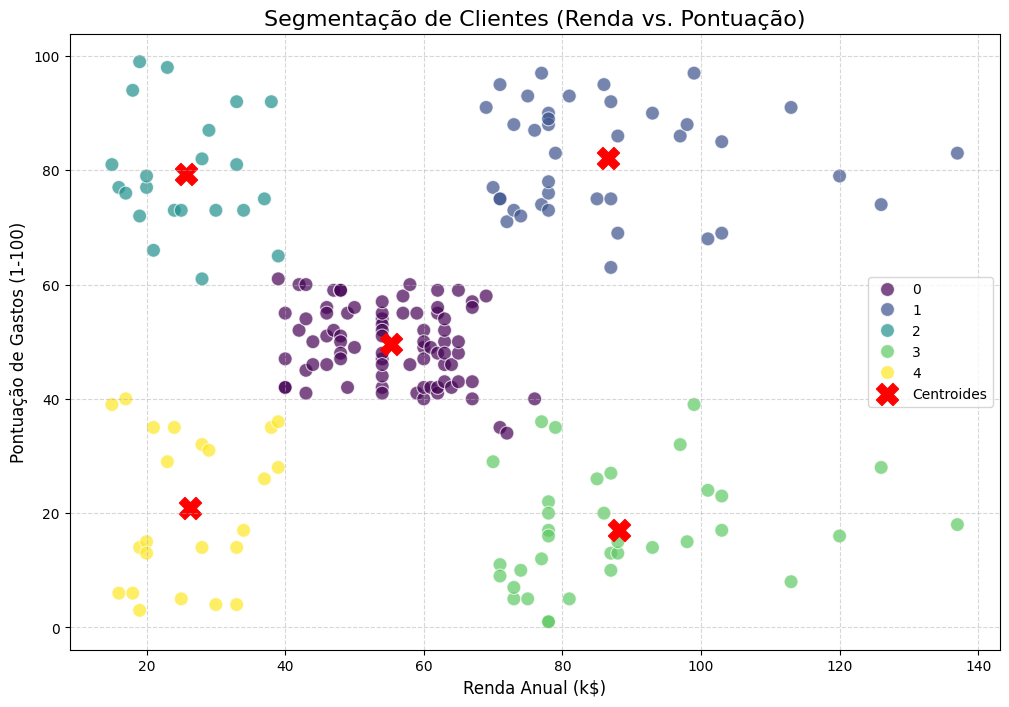

Gerando gráfico de clusters interativo com Plotly...


In [14]:
# --- Passo 9: 
# Treinamento Final e Visualização dos Clusters

K_ideal = 5

print(f"Treinando modelo final com K={K_ideal}...")

# 1. Inicializar e treinar o modelo final
kmeans = KMeans(
    n_clusters=K_ideal, 
    init='k-means++', 
    random_state=42, 
    n_init=10
)

# fit_predict() treina o modelo e retorna o cluster de cada ponto
clusters = kmeans.fit_predict(features_scaled)

# 2. Adicionar os rótulos dos clusters ao DataFrame original
df['Cluster'] = clusters

print("DataFrame com os clusters atribuídos:")
display(df.head())

# 3. Visualizar os clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster',       # Colorir os pontos pelo cluster
    palette='viridis',   # Um bom mapa de cores
    s=100,               # Tamanho dos pontos
    alpha=0.7,
    legend='full'
)

# 4. Plotar os Centroides (os "centros" de cada cluster)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled) # Reverte a escala para plotar

plt.scatter(
    centers[:, 0], centers[:, 1], 
    c='red',         # Cor dos centroides
    s=250,           # Tamanho
    marker='X',      # Marcador
    label='Centroides'
)

plt.title('Segmentação de Clientes (Renda vs. Pontuação)', fontsize=16)
plt.xlabel('Renda Anual (k$)', fontsize=12)
plt.ylabel('Pontuação de Gastos (1-100)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# Salvar o gráfico final
try:
    plt.savefig(CLUSTER_PLOT_FILE, dpi=300)
    print(f"Gráfico de clusters salvo com sucesso em: {CLUSTER_PLOT_FILE}")
except Exception as e:
    print(f"Erro ao salvar o gráfico de clusters: {e}")


# Exibe o gráfico no notebook
plt.show()

# -------------------#

print("Gerando gráfico de clusters interativo com Plotly...")

# Para o Plotly, é melhor tratar o cluster como um 'texto' (categórico)
df_plotly = df.copy()
df_plotly['Cluster'] = df_plotly['Cluster'].astype(str)

# Criar os centroides como um DataFrame separado para plotar
# (A variável 'centers' foi criada na Célula 15)
centers_df = pd.DataFrame(centers, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centers_df['Cluster'] = 'Centroide' # Damos um nome para eles

# --- ESTA É A MUDANÇA (PARÂMETRO 'labels') ---
# Criamos um dicionário para traduzir os nomes das colunas
labels_traduzidos = {
    'Annual Income (k$)': 'Renda Anual (k$)',
    'Spending Score (1-100)': 'Pontuação de Gastos (1-100)',
    'Age': 'Idade',
    'Genre': 'Gênero'
}
# --- FIM DA MUDANÇA ---


# 1. Criar a figura base com os clientes
fig = px.scatter(
    data_frame=df_plotly,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='Cluster',  # Cor por cluster (igual ao 'hue' do seaborn)
    title='Segmentação de Clientes (Gráfico Interativo)',
    
    # Mostra os dados de Idade e Gênero no tooltip
    hover_data=['Age', 'Genre'],
    
    # Força a ordem da legenda de 0 a 4
    category_orders={"Cluster": ["0", "1", "2", "3", "4"]},
    
    # --- APLICA A TRADUÇÃO ---
    labels=labels_traduzidos
)

# 2. Adicionar os centroides (marcadores 'X')
fig.add_scatter(
    x=centers_df['Annual Income (k$)'],
    y=centers_df['Spending Score (1-100)'],
    mode='markers',
    marker_symbol='x',
    marker_color='red',
    marker_size=12,
    name='Centroides' # Nome que aparece na legenda
)

# 3. Exibir o gráfico interativo
fig.show()

## 5. Avaliação (Evaluation)

A etapa de avaliação em um modelo não supervisionado (como K-Means) é dividida em duas partes:

1.  **Avaliação Quantitativa:** Usar uma métrica matemática para medir a "qualidade" da separação dos clusters. Usaremos o **Coeficiente de Silhueta (Silhouette Score)**.
2.  **Avaliação Qualitativa (Negócio):** Analisar o perfil médio de cada cluster para verificar se eles fazem sentido para o negócio.

In [15]:
# --- Passo 10: 
# Avaliação Quantitativa (Silhouette Score)
# Esta é a métrica simples exigida pelo TCC

# O Coeficiente de Silhueta mede o quão bem separados os clusters estão.
# Varia de -1 (péssima clusterização) a 1 (clusters densos e bem separados).
# Valores próximos de 0 indicam sobreposição de clusters.

score = silhouette_score(features_scaled, clusters)

print(f"--- Avaliação do Modelo K-Means (K=5) ---")
print(f"\nCoeficiente de Silhueta: {score:.4f}")

print("\nInterpretação:")
print("Um score acima de 0.5 (como este) indica que os clusters são razoavelmente")
print("densos e bem definidos, validando nossa escolha de K=5.")

--- Avaliação do Modelo K-Means (K=5) ---

Coeficiente de Silhueta: 0.5547

Interpretação:
Um score acima de 0.5 (como este) indica que os clusters são razoavelmente
densos e bem definidos, validando nossa escolha de K=5.


In [16]:
# --- Passo 11: 
# Avaliação Qualitativa (Análise de Perfis)
# O que cada segmento significa para o negócio?

print("--- Análise dos Perfis dos Clusters ---")

# 1. Média das features por cluster
print("\nMédia das features por cluster:")
# Ordenar por Renda Anual ajuda na interpretação
cluster_means = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().sort_values(by='Annual Income (k$)')
display(cluster_means)

# 2. Contagem de Clientes por cluster
print("\nContagem de Clientes por cluster:")
display(df['Cluster'].value_counts().sort_index())

--- Análise dos Perfis dos Clusters ---

Média das features por cluster:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
2,25.272727,25.727273,79.363636
4,45.217391,26.304348,20.913043
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
3,41.114286,88.200000,17.114286



Contagem de Clientes por cluster:


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

--- Análise Gráfica Detalhada dos Clusters ---


C:\Users\s2bcl\AppData\Local\Temp\ipykernel_14944\3067070710.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\s2bcl\AppData\Local\Temp\ipykernel_14944\3067070710.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\s2bcl\AppData\Local\Temp\ipykernel_14944\3067070710.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.





Gráfico de perfis detalhados salvo em: ../reports\perfis_detalhados_clusters.png


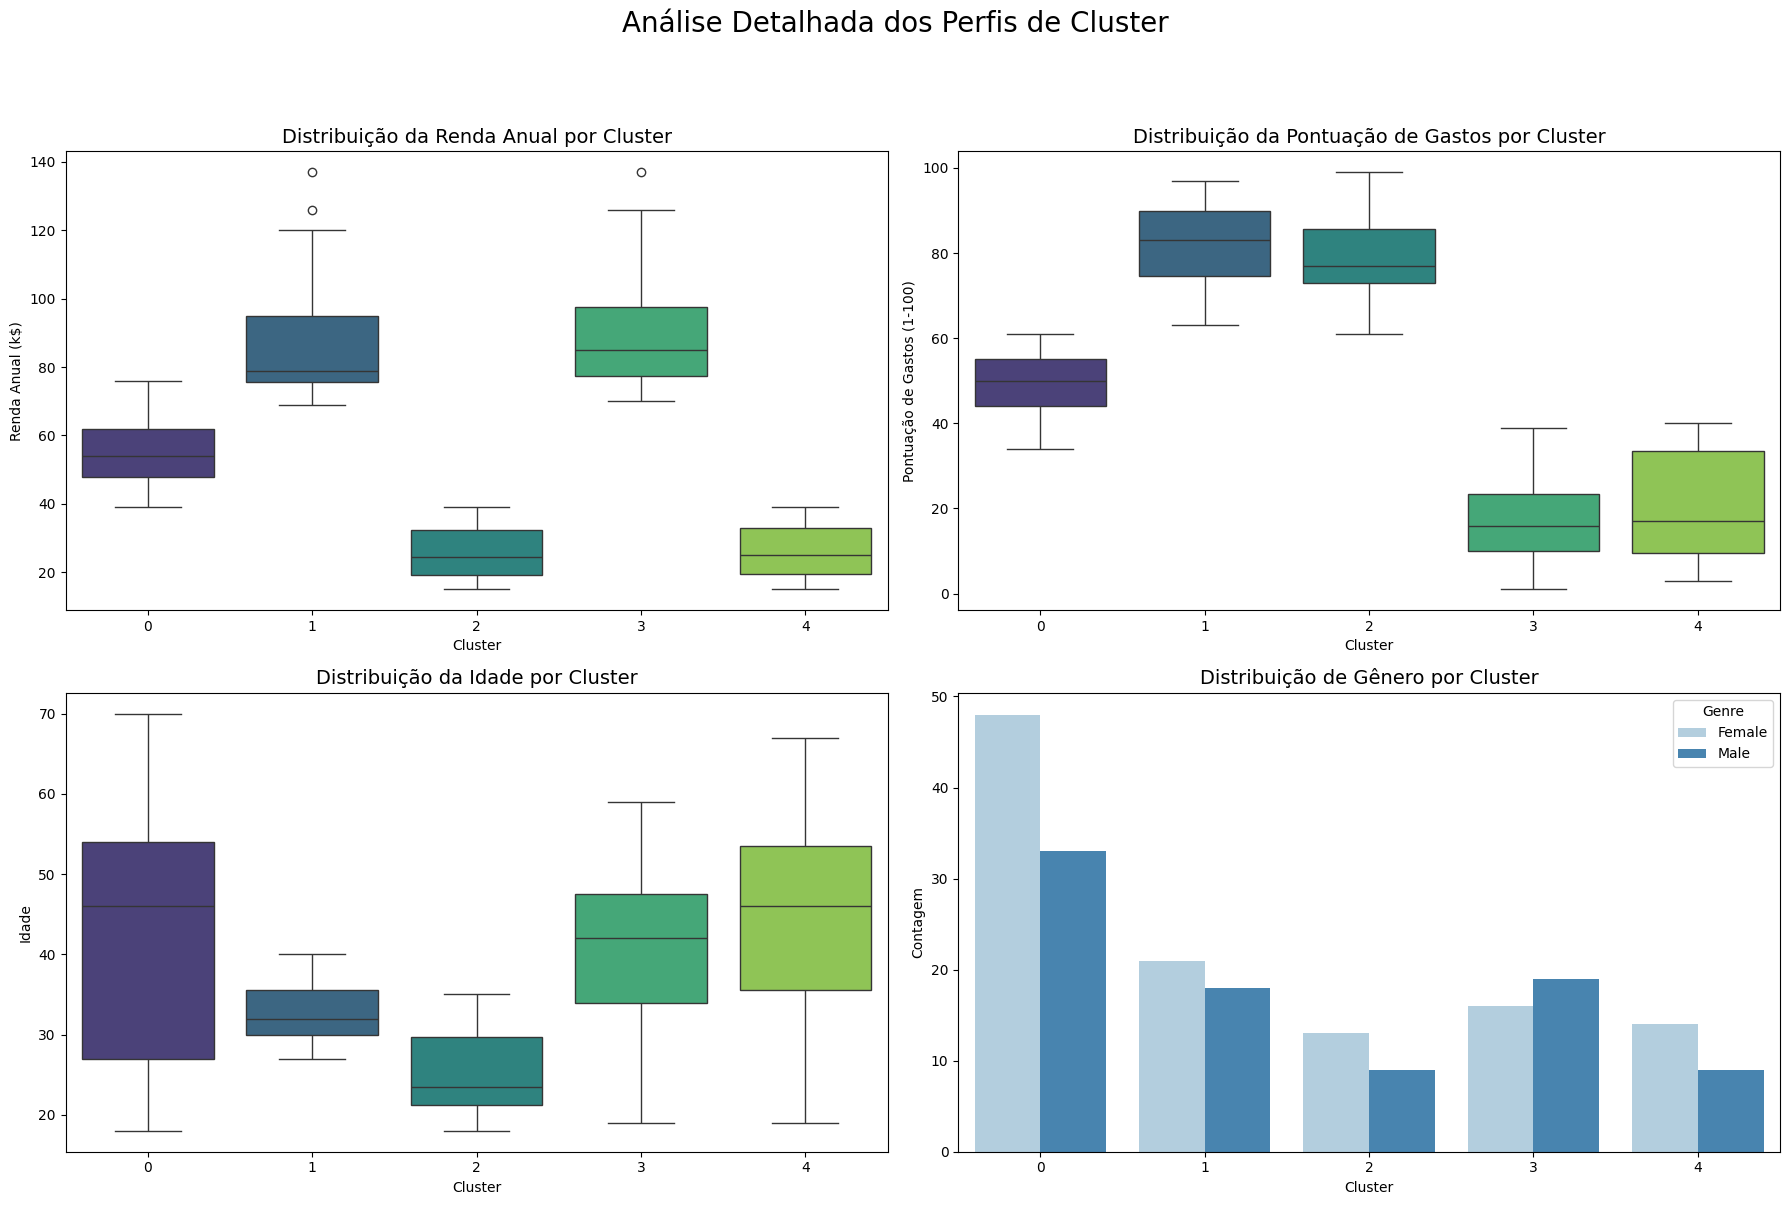

In [17]:
# --- Passo 12: 
# Análise Visual Detalhada dos Perfis
# Aprofundando a análise do Passo 11 com boxplots e countplots.

print("--- Análise Gráfica Detalhada dos Clusters ---")

# Criar uma paleta de cores para os 5 clusters
cluster_palette = sns.color_palette("viridis", n_colors=K_ideal)

# Definir o tamanho da figura (Largura, Altura)
plt.figure(figsize=(18, 12))
plt.suptitle("Análise Detalhada dos Perfis de Cluster", fontsize=20, y=1.03)

# 1. Gráfico: Renda Anual por Cluster (Boxplot)
plt.subplot(2, 2, 1) # (2 linhas, 2 colunas, 1º gráfico)
sns.boxplot(data=df, x='Cluster', y='Annual Income (k$)', palette=cluster_palette)
plt.title('Distribuição da Renda Anual por Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Renda Anual (k$)')

# 2. Gráfico: Pontuação de Gastos por Cluster (Boxplot)
plt.subplot(2, 2, 2) # (2 linhas, 2 colunas, 2º gráfico)
sns.boxplot(data=df, x='Cluster', y='Spending Score (1-100)', palette=cluster_palette)
plt.title('Distribuição da Pontuação de Gastos por Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Pontuação de Gastos (1-100)')

# 3. Gráfico: Idade por Cluster (Boxplot)
# Este gráfico vai revelar insights importantes!
plt.subplot(2, 2, 3) # (2 linhas, 2 colunas, 3º gráfico)
sns.boxplot(data=df, x='Cluster', y='Age', palette=cluster_palette)
plt.title('Distribuição da Idade por Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Idade')

# 4. Gráfico: Gênero por Cluster (Countplot)
plt.subplot(2, 2, 4) # (2 linhas, 2 colunas, 4º gráfico)
sns.countplot(data=df, x='Cluster', hue='Genre', palette='Blues')
plt.title('Distribuição de Gênero por Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Contagem')

# Ajusta o layout para evitar sobreposição
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# Salva a imagem composta
try:
    plt.savefig(PROFILES_PLOT_FILE, dpi=300)
    print(f"\nGráfico de perfis detalhados salvo em: {PROFILES_PLOT_FILE}")
except Exception as e:
    print(f"Erro ao salvar o gráfico de perfis: {e}")

# Exibe os gráficos
plt.show()

In [18]:
# --- Análise Visual Detalhada ---
# Para apresentação.

print("--- Análise Gráfica Interativa Detalhada dos Perfis ---")

# Reutilizar o dicionário de tradução da Célula 16
labels_traduzidos = {
    'Annual Income (k$)': 'Renda Anual (k$)',
    'Spending Score (1-100)': 'Pontuação de Gastos (1-100)',
    'Age': 'Idade',
    'Genre': 'Gênero'
}

# Preparar o DataFrame para o Plotly
df_plotly = df.copy()
df_plotly['Cluster'] = df_plotly['Cluster'].astype(str)
cluster_order = {"Cluster": ["0", "1", "2", "3", "4"]}

# --- Gráfico 1: Renda Anual (Interativo) ---
fig1 = px.box(
    df_plotly,
    x='Cluster',
    y='Annual Income (k$)',
    color='Cluster',
    title='Distribuição da Renda Anual por Cluster (Interativo)',
    labels=labels_traduzidos,
    category_orders=cluster_order
)
fig1.show()

# --- Gráfico 2: Pontuação de Gastos (Interativo) ---
fig2 = px.box(
    df_plotly,
    x='Cluster',
    y='Spending Score (1-100)',
    color='Cluster',
    title='Distribuição da Pontuação de Gastos por Cluster (Interativo)',
    labels=labels_traduzidos,
    category_orders=cluster_order
)
fig2.show()

# --- Gráfico 3: Idade (Interativo) ---
fig3 = px.box(
    df_plotly,
    x='Cluster',
    y='Age',
    color='Cluster',
    title='Distribuição da Idade por Cluster (Interativo)',
    labels=labels_traduzidos,
    category_orders=cluster_order
)
fig3.show()

# --- Gráfico 4: Gênero (Interativo) ---

# Para o countplot, precisamos pré-agregar os dados para o Plotly
df_counts = df_plotly.groupby(['Cluster', 'Genre']).size().reset_index(name='Contagem')

fig4 = px.bar(
    df_counts,
    x='Cluster',
    y='Contagem',
    color='Genre', # Colore as barras por Gênero
    title='Distribuição de Gênero por Cluster (Interativo)',
    labels=labels_traduzidos,
    barmode='group', # Coloca as barras lado a lado
    category_orders=cluster_order
)
fig4.show()

--- Análise Gráfica Interativa Detalhada dos Perfis ---


## 6. Implementação e Conclusões (Deployment)

A etapa final do CRISP-DM é traduzir os resultados da modelagem em ações de negócio. A análise cruzada da tabela de médias (Célula 18) com os gráficos de distribuição (Célula 19) nos permite criar "personas" ricas e acionáveis.

**Conclusões e Estratégias de Negócio:**

* **Cluster 0: "Os Econômicos Ricos"**
    * **Perfil:** Renda Alta (média 88k), Pontuação Baixa (média 17). Os boxplots da Célula 19 mostram que este grupo tem uma idade mais elevada (mediana ~45-50 anos) e uma leve maioria masculina.
    * **Estratégia:** Clientes maduros e de alto valor que não estão sendo convertidos. Sugere-se marketing de relacionamento, produtos premium (ex: vinhos, orgânicos) e investigação de barreiras (mix de produtos? preço?).

* **Cluster 1: "Os Cautelosos"**
    * **Perfil:** Renda Baixa (média 26k), Pontuação Baixa (média 20). O boxplot de Idade mostra uma distribuição ampla, mas com mediana também elevada (~45 anos).
    * **Estratégia:** Clientes focados no essencial. Marketing de baixo custo, focado em promoções de itens básicos, descontos por volume e "compre e ganhe".

* **Cluster 2: "Os Clientes Alvo (VIPs)"**
    * **Perfil:** Renda Alta (média 86k), Pontuação Alta (média 82). A idade é mediana (~32 anos) e o gráfico de Gênero (Célula 19) mostra uma **clara maioria feminina**.
    * **Estratégia:** **Foco total em retenção**. Este é o grupo mais valioso. Programas de fidelidade VIP, *early access* a produtos, atendimento personalizado e marketing de relacionamento. As estratégias devem ter um apelo especial ao público feminino de renda elevada.

* **Cluster 3: "Os Gastadores (Impulsivos)"**
    * **Perfil:** Renda Baixa (média 25k), Pontuação Alta (média 79). Esta era uma hipótese, agora **confirmada pelo boxplot de Idade (Célula 19): a mediana é baixíssima (~25 anos)** e também há uma forte maioria feminina.
    * **Estratégia:** Clientes jovens, sensíveis a tendências mas com baixo poder aquisitivo. Marketing agressivo em redes sociais (TikTok, Instagram), promoções "compre um leve dois", e foco em produtos da moda.

* **Cluster 4: "Os Clientes Padrão"**
    * **Perfil:** O maior grupo de clientes. Renda (55k) e gastos (49) na média. A idade é ampla, mas centrada nos ~45 anos.
    * **Estratégia:** Manter o bom serviço, ofertas sazonais e programas de fidelidade padrão. O objetivo é usar a análise de itens comprados (análise de cesta) para movê-los para o "Cluster 2" (VIP) ou evitar que caiam para o "Cluster 0" (Econômicos).

**Conclusão Final:**
A segmentação foi um sucesso. Os 5 clusters identificados são distintos, bem definidos (validado pelo Coeficiente de Silhueta de **0.55+**) e, o mais importante, acionáveis do ponto de vista de negócios, graças aos *insights* adicionais de idade e gênero.

**ALUNOS**: Façam um encerramento/conclusão do projeto. Repassem os principais aspectos e resultados.